# DengAI final model: reproduce, audit, and submit

This notebook is the executable companion to the final report. It rebuilds the final **city-hybrid MLP** from the competition CSV files and writes a submission in the required 416-row format.

| City | Input representation | Network |
|---|---|---|
| San Juan (`sj`) | 180 multiscale climate summaries + 4 standardized PLS scores | 184 → 100 → 25 → 1 |
| Iquitos (`iq`) | 380 feature-specific lag values | 380 → 70 → 18 → 1 |

The reported final hidden-test MAE is **15.9**. That number is an externally observed leaderboard result: the hidden labels are not available in this repository, so it cannot be recomputed locally. What this notebook *can* verify is the complete data-to-submission path, leakage-safe temporal validation, deterministic reruns in the recorded environment, file format, and (when the exact submitted CSV is supplied) byte-level identity.

> **Important provenance note.** The branch currently contains the pre-PLS reference CSV, not the exact CSV uploaded for the 15.9 result. Put that final file at `artifacts/submission_pls_final_15_9_reference.csv` to activate the exact-hash comparison near the end.

In [30]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from pathlib import Path
import hashlib
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.cross_decomposition import PLSRegression


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "data" / "dengue_features_train.csv").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from the DengAI repository or its Main/ folder.")


ROOT = find_project_root()
DATA = ROOT / "data"
ARTIFACTS = ROOT / "artifacts"
OUTPUTS = ROOT / "Main" / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

KEYS = ["city", "year", "weekofyear"]
DATE = "week_start_date"
TARGET = "total_cases"
SEED = 42

print("Project root:", ROOT)
print({"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "sklearn": sklearn.__version__})

Project root: /Users/dangnq2501/Desktop/my_projects/MBZUAI/code/AI-7101/DengAI
{'python': '3.12.13', 'numpy': '2.4.4', 'pandas': '3.0.2', 'sklearn': '1.8.0'}


## 1. Load and audit the competition data

We join labels with features by the official three-column key and assert a one-to-one relationship. The test keys must match the submission template exactly. These assertions fail early if files are mixed from different dataset versions.

In [31]:
features = pd.read_csv(DATA / "dengue_features_train.csv")
labels = pd.read_csv(DATA / "dengue_labels_train.csv")
test = pd.read_csv(DATA / "dengue_features_test.csv")
template = pd.read_csv(DATA / "submission_format.csv")

train = features.merge(labels, on=KEYS, how="inner", validate="one_to_one")
assert len(train) == len(features) == len(labels)
assert test[KEYS].equals(template[KEYS])
for frame in (train, test):
    frame[DATE] = pd.to_datetime(frame[DATE])

audit = pd.DataFrame({
    "train_weeks": train.groupby("city").size(),
    "test_weeks": test.groupby("city").size(),
    "median_cases": train.groupby("city")[TARGET].median(),
    "mean_cases": train.groupby("city")[TARGET].mean().round(2),
    "max_cases": train.groupby("city")[TARGET].max(),
})
display(audit)
print("Shapes:", {"train": train.shape, "test": test.shape, "template": template.shape})

,train_weeks,test_weeks,median_cases,mean_cases,max_cases
city,,,,,
iq,520,156,5.0,7.57,116
sj,936,260,19.0,34.18,461


Shapes: {'train': (1456, 25), 'test': (416, 24), 'template': (416, 4)}


### Why two city-specific models?

San Juan has more and much larger outbreaks; Iquitos has lower counts and many quiet weeks. A single loss surface would be dominated by San Juan, while the two cities also have different useful memory lengths. We therefore share the *method* but not the fitted model.

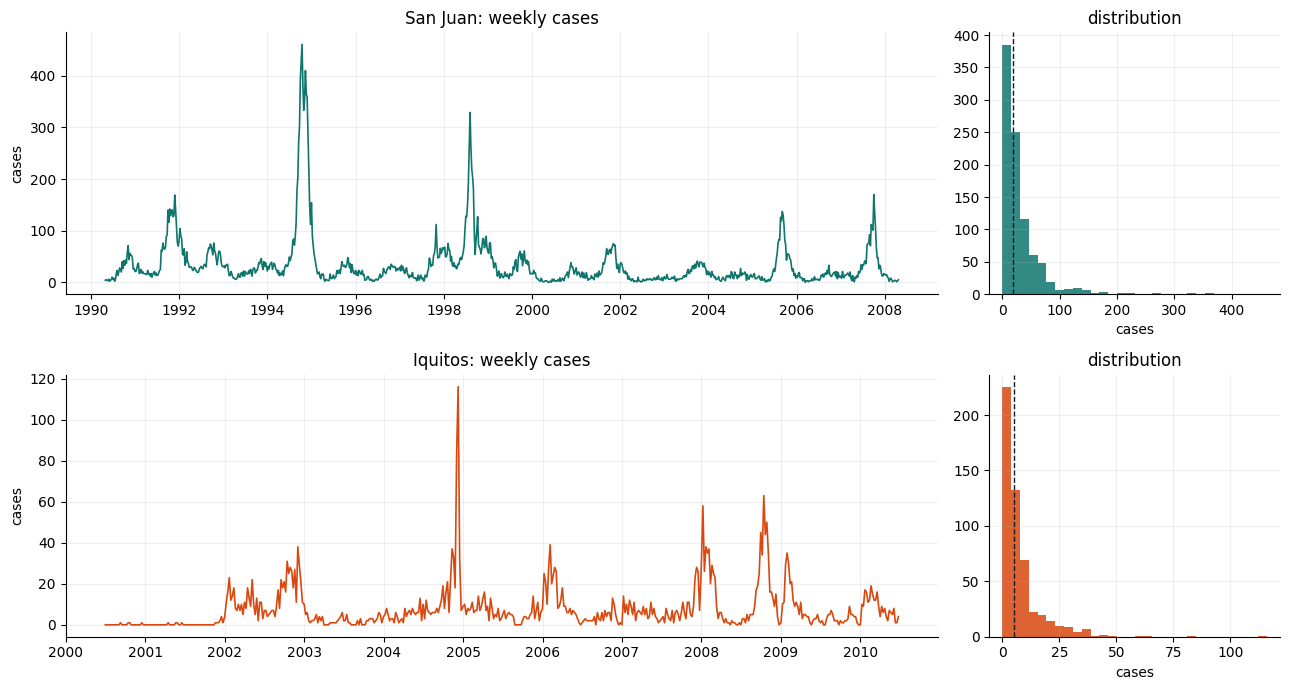

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), gridspec_kw={"width_ratios": [3, 1]})
palette = {"sj": "#0f766e", "iq": "#d9480f"}
for row, (city, name) in enumerate([("sj", "San Juan"), ("iq", "Iquitos")]):
    d = train.loc[train.city.eq(city)].sort_values(DATE)
    axes[row, 0].plot(d[DATE], d[TARGET], color=palette[city], lw=1.2)
    axes[row, 0].set(title=f"{name}: weekly cases", ylabel="cases")
    axes[row, 1].hist(d[TARGET], bins=30, color=palette[city], alpha=.85)
    axes[row, 1].axvline(d[TARGET].median(), color="#111827", ls="--", lw=1)
    axes[row, 1].set(title="distribution", xlabel="cases")
for ax in axes.flat:
    ax.grid(alpha=.2)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Missing values and normalization

There are two preprocessing regimes in the project:

| Model family | Missing values | Normalization | Reason |
|---|---|---|---|
| Tree ensembles | fold-fitted median imputation | none | split thresholds are invariant to monotone rescaling |
| MLP (final) | linear interpolation in time order | z-score weather; min-max week | gradient optimization is scale-sensitive and lag windows must remain continuous |

The final MLP preserves the experiment's `shared-sj` scaling: San Juan weather means and standard deviations are used for both cities. This is unusual, but keeping it fixed isolates later representation changes from a normalization change.

In [33]:
WEATHER = [
    "precipitation_amt_mm", "reanalysis_air_temp_k", "reanalysis_avg_temp_k",
    "reanalysis_dew_point_temp_k", "reanalysis_max_air_temp_k", "reanalysis_min_air_temp_k",
    "reanalysis_precip_amt_kg_per_m2", "reanalysis_relative_humidity_percent",
    "reanalysis_sat_precip_amt_mm", "reanalysis_specific_humidity_g_per_kg",
    "reanalysis_tdtr_k", "station_avg_temp_c", "station_diur_temp_rng_c",
    "station_max_temp_c", "station_min_temp_c", "station_precip_mm",
]


def interpolate_numeric(frame):
    out = frame.copy()
    numeric = out.select_dtypes(include="number").columns
    out[numeric] = out[numeric].interpolate(method="linear", limit_direction="forward")
    return out


def fit_shared_sj_scaler(interpolated_train):
    sj = interpolated_train.loc[interpolated_train.city.eq("sj")].reset_index(drop=True)
    reference = pd.concat([sj.iloc[-53:], sj], ignore_index=True)
    params = {name: (float(np.nanmean(reference[name])), float(np.nanstd(reference[name]))) for name in WEATHER}
    params["weekofyear"] = (float(reference.weekofyear.min()), float(reference.weekofyear.max()))
    return params


def scale_columns(frame, params):
    scaled = {
        name: (frame[name].to_numpy(float) - params[name][0]) / max(params[name][1], 1e-12)
        for name in WEATHER
    }
    lo, hi = params["weekofyear"]
    scaled["weekofyear"] = (frame.weekofyear.to_numpy(float) - lo) / max(hi - lo, 1.0)
    return scaled


train_i = interpolate_numeric(train)
test_i = interpolate_numeric(test)
scaler = fit_shared_sj_scaler(train_i)
assert train_i[WEATHER].notna().all().all() and test_i[WEATHER].notna().all().all()

missing = (features.drop(columns=KEYS + [DATE]).isna().mean().sort_values(ascending=False) * 100)
display(missing[missing.gt(0)].rename("missing_percent").to_frame().head(12).round(2))

,missing_percent
ndvi_ne,13.32
ndvi_nw,3.57
station_diur_temp_rng_c,2.95
station_avg_temp_c,2.95
station_precip_mm,1.51
ndvi_sw,1.51
ndvi_se,1.51
station_max_temp_c,1.37
station_min_temp_c,0.96
precipitation_amt_mm,0.89


## 3. Feature engineering: from 461 coordinates to 180 climate-state summaries

The raw SJ MLP had 461 inputs: consecutive lag windows for 16 weather variables plus week of year. That representation preserved detail but forced a small network to learn averaging, volatility, trend, and seasonality from hundreds of correlated coordinates.

For each of the 16 weather series, the final multiscale representation keeps 11 deliberately chosen statistics:

1. latest level;
2. means over 2, 4, 8, 13, 26, and 52 weeks;
3. standard deviation over 4 and 13 weeks;
4. 4-week mean minus 13-week mean;
5. 13-week slope.

Four annual/semiannual sine-cosine terms are appended. Therefore `16 × 11 + 4 = 180`.

The 24 raw feature columns are not all expanded. Four are keys/date, four are NDVI. NDVI was useful in trees, but its missingness and weak temporal stability made it less reliable for the final lag MLP; the 16 consistently defined weather series are the expanded variables.

In [34]:
MEAN_WINDOWS = (2, 4, 8, 13, 26, 52)
STD_WINDOWS = (4, 13)
SUMMARY_DIM = len(WEATHER) * 11 + 4


def multiscale_rows(combined, params, n_rows):
    scaled = scale_columns(combined, params)
    weeks = combined.weekofyear.to_numpy(float)
    rows = []
    for i in range(n_rows):
        end = 51 + i  # historical two-row alignment retained for model compatibility
        parts = []
        for name in WEATHER:
            history = scaled[name][end - 51:end + 1]
            means = {window: float(np.mean(history[-window:])) for window in MEAN_WINDOWS}
            parts.extend([
                float(history[-1]),
                *(means[window] for window in MEAN_WINDOWS),
                *(float(np.std(history[-window:])) for window in STD_WINDOWS),
                means[4] - means[13],
                float((history[-1] - history[-13]) / 12.0),
            ])
        phase = 2 * np.pi * (weeks[end] - 1) / 52
        parts.extend([np.sin(phase), np.cos(phase), np.sin(2 * phase), np.cos(2 * phase)])
        rows.append(parts)
    matrix = np.asarray(rows, dtype="float32")
    assert matrix.shape == (n_rows, SUMMARY_DIM) and np.isfinite(matrix).all()
    return matrix


def city_frames(city, train_frame=train_i, test_frame=test_i):
    tr = train_frame.loc[train_frame.city.eq(city)].sort_values(DATE).reset_index(drop=True)
    te = test_frame.loc[test_frame.city.eq(city)].sort_values(DATE).reset_index(drop=True)
    return tr, te


def multiscale_train_test(city, train_frame=train_i, test_frame=test_i, params=scaler):
    tr, te = city_frames(city, train_frame, test_frame)
    train_combined = pd.concat([tr.iloc[-53:], tr], ignore_index=True)
    test_combined = pd.concat([tr.iloc[-53:], te], ignore_index=True)
    x_train = multiscale_rows(train_combined, params, len(tr))
    y_train = train_combined[TARGET].to_numpy(float)[51:51 + len(tr)].astype("float32")
    x_test = multiscale_rows(test_combined, params, len(te))
    return x_train, y_train, x_test


X_sj_180, y_sj, Xte_sj_180 = multiscale_train_test("sj")
print("San Juan multiscale shapes:", X_sj_180.shape, y_sj.shape, Xte_sj_180.shape)

San Juan multiscale shapes: (936, 180) (936,) (260, 180)


## 4. PLS augmentation: four target-aware directions

The 180 summaries are stable but correlated. Partial Least Squares learns a few linear combinations that covary with dengue cases. We **append** four standardized PLS scores instead of replacing the original summaries, so the MLP keeps all nonlinear and seasonal detail.

PLS is supervised. During validation it must be fitted only on the earlier training window; fitting it on the full series before splitting would leak validation labels.

In [35]:
PLS_COMPONENTS = 4


def fit_pls_augmentation(x_train, y_train, x_eval, components=PLS_COMPONENTS):
    model = PLSRegression(n_components=components, scale=True, max_iter=1000, tol=1e-7, copy=True)
    model.fit(x_train, np.asarray(y_train).reshape(-1, 1))
    train_scores = model.transform(x_train)
    eval_scores = model.transform(x_eval)
    score_mean = train_scores.mean(axis=0)
    score_scale = train_scores.std(axis=0)
    score_scale = np.where(score_scale < 1e-8, 1.0, score_scale)
    train_scores = (train_scores - score_mean) / score_scale
    eval_scores = (eval_scores - score_mean) / score_scale
    return (
        model,
        np.concatenate([x_train, train_scores], axis=1).astype("float32"),
        np.concatenate([x_eval, eval_scores], axis=1).astype("float32"),
        score_mean,
        score_scale,
    )


pls_sj, X_sj, Xte_sj, pls_mean, pls_scale = fit_pls_augmentation(X_sj_180, y_sj, Xte_sj_180)
assert X_sj.shape[1] == Xte_sj.shape[1] == 184
print("PLS-augmented San Juan shapes:", X_sj.shape, Xte_sj.shape)

PLS-augmented San Juan shapes: (936, 184) (260, 184)


## 5. Deterministic NumPy MLP

The model has two hidden layers (the output makes it a three-layer perceptron), SELU activations, inverted dropout, a linear output, MAE loss, RMSprop, gradient clipping, and learning-rate reduction on a plateau. No prior case count is used as an input.

In [36]:
ALPHA = 1.6732632423543772
SCALE = 1.0507009873554805


def selu(x):
    return SCALE * np.where(x > 0, x, ALPHA * np.expm1(np.clip(x, -30, 0)))


def dselu(x):
    return SCALE * np.where(x > 0, 1.0, ALPHA * np.exp(np.clip(x, -30, 0)))


def predict_mlp(weights, matrix):
    w1, b1, w2, b2, w3, b3 = weights
    matrix = np.asarray(matrix, np.float64)
    return (selu(selu(matrix @ w1 + b1) @ w2 + b2) @ w3 + b3).reshape(-1)


def fit_mlp(x, y, city, h1, h2, drop1, drop2, learning_rate, seed=SEED,
            epochs=40, steps=200, batch_size=16, validation=None):
    x = np.asarray(x, np.float64)
    y = np.asarray(y, np.float64).reshape(-1, 1)
    rng = np.random.default_rng(seed)
    glorot = lambda i, o: rng.uniform(-np.sqrt(6 / (i + o)), np.sqrt(6 / (i + o)), (i, o))
    weights = [
        glorot(x.shape[1], h1), np.zeros((1, h1)),
        glorot(h1, h2), np.zeros((1, h2)),
        glorot(h2, 1), np.zeros((1, 1)),
    ]
    rms = [np.zeros_like(value) for value in weights]
    rho, eps = .9, 1e-7
    keep1, keep2 = 1 - drop1, 1 - drop2
    patience = 3 if city == "sj" else 5
    order, position, best, stale = rng.permutation(len(x)), 0, np.inf, 0
    history = []
    lr = learning_rate
    for epoch in range(epochs):
        batch_errors = []
        for _ in range(steps):
            if position >= len(order):
                if city == "sj":
                    order = rng.permutation(len(x))
                position = 0
            idx = order[position:position + batch_size]
            position += len(idx)
            xb, yb = x[idx], y[idx]
            w1, b1, w2, b2, w3, b3 = weights
            z1 = xb @ w1 + b1
            a1 = selu(z1)
            mask1 = rng.random(a1.shape) < keep1
            d1 = a1 * mask1 / keep1
            z2 = d1 @ w2 + b2
            a2 = selu(z2)
            mask2 = rng.random(a2.shape) < keep2
            d2 = a2 * mask2 / keep2
            pred = d2 @ w3 + b3
            batch_errors.append(float(np.mean(np.abs(pred - yb))))
            grad = np.sign(pred - yb) / len(idx)
            dz2 = (grad @ w3.T) * dselu(z2) * mask2 / keep2
            dz1 = ((dz2 @ w2.T) * mask1 / keep1) * dselu(z1)
            gradients = [xb.T @ dz1, dz1.sum(0, keepdims=True), d1.T @ dz2,
                         dz2.sum(0, keepdims=True), d2.T @ grad, grad.sum(0, keepdims=True)]
            for k, gradient in enumerate(gradients):
                gradient = np.clip(gradient, -100, 100)
                rms[k] = rho * rms[k] + (1 - rho) * gradient ** 2
                weights[k] -= lr * gradient / (np.sqrt(rms[k]) + eps)
        dropout_mae = float(np.mean(batch_errors))
        row = {
            "epoch": epoch + 1,
            "dropout_train_mae": dropout_mae,
            "clean_train_mae": float(np.mean(np.abs(predict_mlp(weights, x) - y.ravel()))),
            "learning_rate": lr,
        }
        if validation is not None:
            val_x, val_y = validation
            val_pred = np.floor(np.maximum(predict_mlp(weights, val_x), 0) + .5)
            row["validation_mae"] = float(np.mean(np.abs(val_pred - val_y)))
        history.append(row)
        if dropout_mae < best:
            best, stale = dropout_mae, 0
        else:
            stale += 1
        if stale >= patience:
            lr, stale = max(lr * .8, 1e-6), 0
    return weights, pd.DataFrame(history)

## 6. Iquitos raw-history representation

The final hybrid leaves Iquitos on the tuned raw-lag representation. A window length is selected per weather series; all consecutive values inside that window are retained. The lengths sum to 380 inputs.

In [37]:
IQ_LAGS = {
    "precipitation_amt_mm": 33, "reanalysis_air_temp_k": 10, "reanalysis_avg_temp_k": 4,
    "reanalysis_dew_point_temp_k": 6, "reanalysis_max_air_temp_k": 41,
    "reanalysis_min_air_temp_k": 40, "reanalysis_precip_amt_kg_per_m2": 3,
    "reanalysis_relative_humidity_percent": 7, "reanalysis_sat_precip_amt_mm": 33,
    "reanalysis_specific_humidity_g_per_kg": 26, "reanalysis_tdtr_k": 34,
    "station_avg_temp_c": 40, "station_diur_temp_rng_c": 26, "station_max_temp_c": 39,
    "station_min_temp_c": 25, "station_precip_mm": 10, "weekofyear": 3,
}


def raw_lag_rows(combined, params, n_rows, windows):
    scaled = scale_columns(combined, params)
    rows = [
        np.concatenate([scaled[name][51 + i - width + 1:52 + i] for name, width in windows.items()])
        for i in range(n_rows)
    ]
    return np.vstack(rows).astype("float32")


iq_train, iq_test = city_frames("iq")
iq_train_combined = pd.concat([iq_train.iloc[-53:], iq_train], ignore_index=True)
iq_test_combined = pd.concat([iq_train.iloc[-53:], iq_test], ignore_index=True)
X_iq = raw_lag_rows(iq_train_combined, scaler, len(iq_train), IQ_LAGS)
y_iq = iq_train_combined[TARGET].to_numpy(float)[51:51 + len(iq_train)].astype("float32")
Xte_iq = raw_lag_rows(iq_test_combined, scaler, len(iq_test), IQ_LAGS)
assert X_iq.shape[1] == Xte_iq.shape[1] == sum(IQ_LAGS.values()) == 380
print("Iquitos raw-lag shapes:", X_iq.shape, y_iq.shape, Xte_iq.shape)

Iquitos raw-lag shapes: (520, 380) (520,) (156, 380)


## 7. Leakage-safe chronological hold-out

This cell demonstrates the critical rule for PLS: the projection is fitted using only the earlier training block. The final 52 San Juan weeks are transformed with that frozen projection; their labels never shape the PLS directions.

In [38]:
HOLDOUT_WEEKS = 52
sj_raw = train.loc[train.city.eq("sj")].sort_values(DATE).reset_index(drop=True)
cut = len(sj_raw) - HOLDOUT_WEEKS
fold_train_raw = sj_raw.iloc[:cut].copy()
fold_valid_raw = sj_raw.iloc[cut:].copy()

# The shared-SJ scaler and representation are refitted using fold-training rows only.
fold_train_i = interpolate_numeric(fold_train_raw)
fold_valid_i = interpolate_numeric(fold_valid_raw.drop(columns=[TARGET]))
fold_scaler = fit_shared_sj_scaler(fold_train_i)
X_fold_180, y_fold, X_valid_180 = multiscale_train_test(
    "sj", fold_train_i, fold_valid_i, fold_scaler
)
fold_pls, X_fold, X_valid, _, _ = fit_pls_augmentation(X_fold_180, y_fold, X_valid_180)
y_valid = fold_valid_raw[TARGET].to_numpy(float)

W_cv, history_cv = fit_mlp(
    X_fold, y_fold, "sj", 100, 25, .30, .70, .01,
    epochs=28, steps=120, validation=(X_valid, y_valid)
)
valid_pred = np.floor(np.maximum(predict_mlp(W_cv, X_valid), 0) + .5)
holdout_mae = float(np.mean(np.abs(valid_pred - y_valid)))
print(f"San Juan 52-week PLS hold-out MAE: {holdout_mae:.3f}")

San Juan 52-week PLS hold-out MAE: 19.269


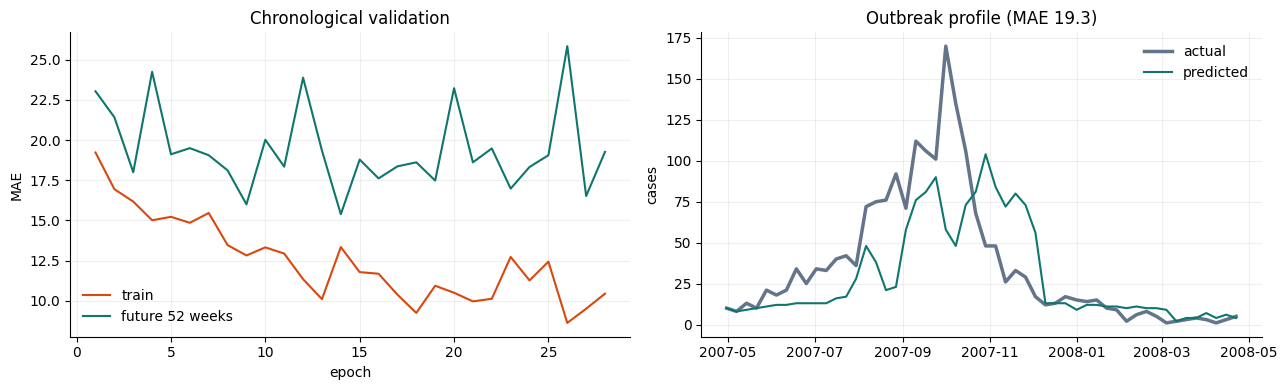

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_cv.epoch, history_cv.clean_train_mae, label="train", color="#d9480f")
axes[0].plot(history_cv.epoch, history_cv.validation_mae, label="future 52 weeks", color="#0f766e")
axes[0].set(title="Chronological validation", xlabel="epoch", ylabel="MAE")
axes[0].legend(frameon=False)
axes[1].plot(fold_valid_raw[DATE], y_valid, label="actual", color="#64748b", lw=2.5)
axes[1].plot(fold_valid_raw[DATE], valid_pred, label="predicted", color="#0f766e", lw=1.5)
axes[1].set(title=f"Outbreak profile (MAE {holdout_mae:.1f})", ylabel="cases")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=.2)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### What the four PLS scores capture

The bars below are diagnostics, not inputs to model selection. Each component is learned from the earlier training block only. We then measure its correlation with cases in both the training block and the unseen future block. The loading chart shows which original summaries contribute most strongly to the first supervised direction.

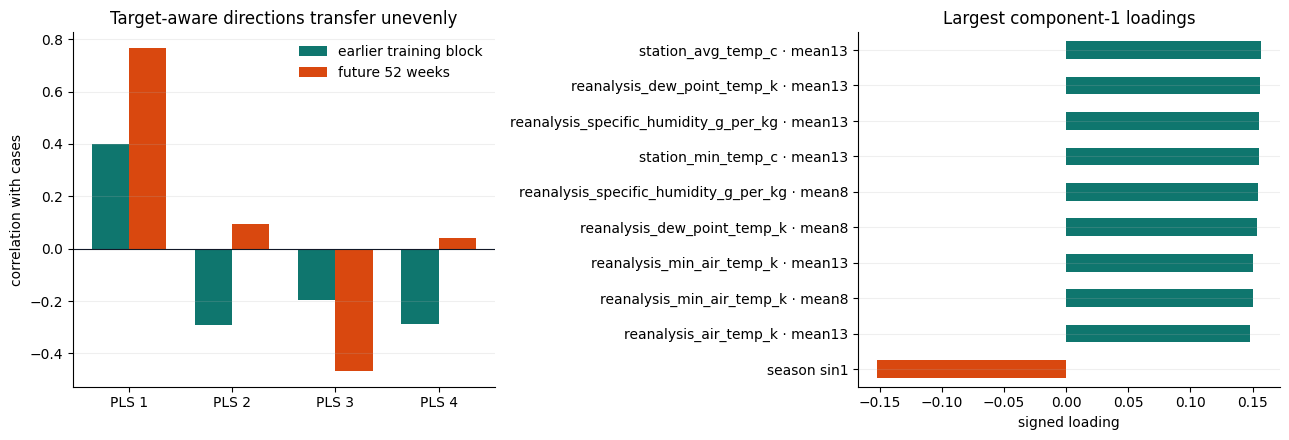

,component,train_corr,future_corr
0,PLS 1,0.398,0.765
1,PLS 2,-0.292,0.094
2,PLS 3,-0.196,-0.466
3,PLS 4,-0.287,0.041


In [40]:
train_scores = fold_pls.transform(X_fold_180)
valid_scores = fold_pls.transform(X_valid_180)
train_corr = [np.corrcoef(train_scores[:, i], y_fold)[0, 1] for i in range(PLS_COMPONENTS)]
valid_corr = [np.corrcoef(valid_scores[:, i], y_valid)[0, 1] for i in range(PLS_COMPONENTS)]

stat_names = ["latest", "mean2", "mean4", "mean8", "mean13", "mean26", "mean52",
              "std4", "std13", "mean4-mean13", "slope13"]
summary_names = [f"{weather} · {stat}" for weather in WEATHER for stat in stat_names]
summary_names += ["season sin1", "season cos1", "season sin2", "season cos2"]
loadings = pd.Series(fold_pls.x_loadings_[:, 0], index=summary_names)
top = loadings.loc[loadings.abs().nlargest(10).index].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(PLS_COMPONENTS)
axes[0].bar(x - .18, train_corr, .36, label="earlier training block", color="#0f766e")
axes[0].bar(x + .18, valid_corr, .36, label="future 52 weeks", color="#d9480f")
axes[0].axhline(0, color="#111827", lw=.8)
axes[0].set(xticks=x, xticklabels=[f"PLS {i+1}" for i in x], ylabel="correlation with cases",
            title="Target-aware directions transfer unevenly")
axes[0].legend(frameon=False)
top.plot.barh(ax=axes[1], color=np.where(top.ge(0), "#0f766e", "#d9480f"))
axes[1].set(title="Largest component-1 loadings", xlabel="signed loading", ylabel="")
for ax in axes:
    ax.grid(axis="y", alpha=.2)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
pls_figure_path = OUTPUTS / "pls_components_actual.png"
plt.savefig(pls_figure_path, dpi=180, bbox_inches="tight")
plt.show()

display(pd.DataFrame({"component": [f"PLS {i+1}" for i in x],
                      "train_corr": train_corr, "future_corr": valid_corr}).round(3))

## 8. Fit the final models on all training weeks

The seed, architecture, dropout, learning rate, schedule, and integer conversion are fixed before training. San Juan uses nearest-integer rounding after clipping at zero; Iquitos retains the historical truncation rule.

In [41]:
W_sj, history_sj = fit_mlp(X_sj, y_sj, "sj", 100, 25, .30, .70, .01, seed=SEED)
W_iq, history_iq = fit_mlp(X_iq, y_iq, "iq", 70, 18, .50, .50, .001, seed=SEED)

sj_raw_prediction = predict_mlp(W_sj, Xte_sj)
iq_raw_prediction = predict_mlp(W_iq, Xte_iq)
sj_cases = np.floor(np.maximum(sj_raw_prediction, 0) + .5).astype(int)
iq_cases = np.maximum(iq_raw_prediction, 0).astype(int)

training_summary = pd.DataFrame([
    {"city": "sj", "inputs": X_sj.shape[1], "h1": 100, "h2": 25,
     "train_mae": np.mean(np.abs(predict_mlp(W_sj, X_sj) - y_sj)),
     "test_mean": sj_cases.mean(), "test_max": sj_cases.max()},
    {"city": "iq", "inputs": X_iq.shape[1], "h1": 70, "h2": 18,
     "train_mae": np.mean(np.abs(predict_mlp(W_iq, X_iq) - y_iq)),
     "test_mean": iq_cases.mean(), "test_max": iq_cases.max()},
])
display(training_summary.round(3))

,city,inputs,h1,h2,train_mae,test_mean,test_max
0,sj,184,100,25,9.873,50.062,289
1,iq,380,70,18,2.384,4.776,19


## 9. Assemble and validate the submission

The output is merged back to the official template order, converted to non-negative integers, checked for missing/duplicate keys, and hashed. This is the file to submit.

In [42]:
def prediction_frame(city, cases):
    city_test = test.loc[test.city.eq(city)].sort_values(DATE).reset_index(drop=True)
    out = city_test[KEYS].copy()
    out[TARGET] = np.asarray(cases, dtype=int)
    return out


predictions = pd.concat([
    prediction_frame("sj", sj_cases),
    prediction_frame("iq", iq_cases),
], ignore_index=True)
submission = template[KEYS].merge(predictions, on=KEYS, how="left", validate="one_to_one", sort=False)
submission[TARGET] = submission[TARGET].astype(int)

assert len(submission) == 416
assert submission[KEYS].equals(template[KEYS])
assert submission[TARGET].notna().all()
assert submission[TARGET].ge(0).all()
assert not submission.duplicated(KEYS).any()

submission_path = OUTPUTS / "submission_pls_final_reproduced.csv"
submission.to_csv(submission_path, index=False)
sha256 = hashlib.sha256(submission_path.read_bytes()).hexdigest()
print("Submission:", submission_path)
print("Rows:", len(submission), "SHA-256:", sha256)
display(submission.groupby("city")[TARGET].agg(["count", "mean", "median", "max"]).round(2))

Submission: /Users/dangnq2501/Desktop/my_projects/MBZUAI/code/AI-7101/DengAI/Main/outputs/submission_pls_final_reproduced.csv
Rows: 416 SHA-256: 8d02e6dc6bd0026e31f5fedd70935ecaf5bc15708aaf423d7802d61e02d200bf


,count,mean,median,max
city,,,,
iq,156,4.78,4.0,19
sj,260,50.06,18.0,289


In [43]:
reference_path = ARTIFACTS / "submission_pls_final_15_9_reference.csv"
if reference_path.exists():
    reference = pd.read_csv(reference_path)
    reference_hash = hashlib.sha256(reference_path.read_bytes()).hexdigest()
    same_values = submission.equals(reference)
    print("Reference SHA-256:", reference_hash)
    print("Exact values match:", same_values)
    if not same_values:
        comparison = submission.merge(reference, on=KEYS, suffixes=("_new", "_reference"))
        difference = (comparison[f"{TARGET}_new"] - comparison[f"{TARGET}_reference"]).abs()
        display(comparison.assign(abs_difference=difference).groupby("city").abs_difference.agg(["mean", "max", "count"]))
else:
    print("Reference check skipped: add the exact 15.9 submitted CSV at", reference_path)

Reference check skipped: add the exact 15.9 submitted CSV at /Users/dangnq2501/Desktop/my_projects/MBZUAI/code/AI-7101/DengAI/artifacts/submission_pls_final_15_9_reference.csv


## 10. What has—and has not—been reproduced

| Claim | Evidence in this notebook |
|---|---|
| Final method is 180 multiscale summaries + 4 PLS scores for SJ | feature dimensions asserted at 180 and 184 |
| PLS validation is leakage-safe | projector fitted inside the chronological training block |
| IQ remains a 380-input raw-lag model | lag lengths and shape asserted |
| Submission is ready for upload | 416 rows, official order, integer/non-negative checks, SHA-256 printed |
| Hidden MAE is 15.9 | external leaderboard observation; cannot be recomputed without hidden labels |
| Exact uploaded bytes reproduced | verified only when `submission_pls_final_15_9_reference.csv` is supplied |

This boundary is intentional. A convincing reproducibility claim should never infer a hidden score from local validation or treat a stale saved notebook output as a fresh execution result.